In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

Importation des données

In [46]:
df = pd.read_csv(r"D:\Code_data\DESU_ROCHET\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)

C:\Users\julie\AppData\Local\Temp\ipykernel_7008\3676364302.py:1: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\Code_data\DESU_ROCHET\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)


In [48]:
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1714301721,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1743653496,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
df.shape

(1000, 211)

In [41]:
with open("colonnes.txt", "w") as f:
    for col in df.columns:
        f.write(col + "\n") ### ça créer un fichier texte avec le nom de TOUTES les colonnes du dataframe

#il y a une colomne nomée nutriscore_grade avec des valeurs de type objet (str)


In [58]:
print(df["nutriscore_grade"].dtype)

print(df["nutriscore_grade"].unique())

print(df["nutriscore_grade"].value_counts())

#on a ~ 30% de nos aliments qui ont un nutriscore connu. 
#on train sur ces 30% et on test sur les autres 70% pour prédire le nutriscore des aliments qui n'ont pas de nutriscore connu.
#puis on vérifie si les scores calculés sont cohérents avec les autres informations nutritionnelles de l'aliment avec des graphiques. Comme des boxplot pour chaque catégorie (A, B..) en fonction du sucre par exemple. 
#MAIS on peut AUSSI couper les 30% en deux parties, une pour le train et une pour le test, pour évaluer la performance de notre modèle.
#je trouve ça mieux car au moins on a nos score, on peut faire nos training curve etc .. Puis on peut ensuite appliquer le modèle sur les 70% restants pour prédire le nutriscore des aliments qui n'ont pas de nutriscore connu.

str
<StringArray>
['unknown', nan, 'c', 'a', 'not-applicable', 'e', 'd', 'b']
Length: 8, dtype: str
nutriscore_grade
unknown           8455
e                  306
not-applicable     267
d                  209
c                  190
a                  171
b                   89
Name: count, dtype: int64


Spliter les données en deux parties : une pour l'entraînement et une pour le test. 

In [57]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["nutriscore_grade"])   # nos variables explicatives
y = df["nutriscore_grade"]                   # ce qu'on veut prédire

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#test_size should be between 0.0 and 1.0 and represent the proportion of the dataset to include in the test split.

##la ça prend tout le jeu de données donc pas bien. 
#Il faut le faire sur les 30% des données avec nutriscore connu, donc créons un nouveau dataframe?

PREPARATION DES DONNEES

Gérer données manquantes 

In [55]:
#Nettoyage minimal des données
percent_missing = df.isnull().sum() * 100 / len(df)
percent_missing.sort_values(ascending=False,inplace=True)

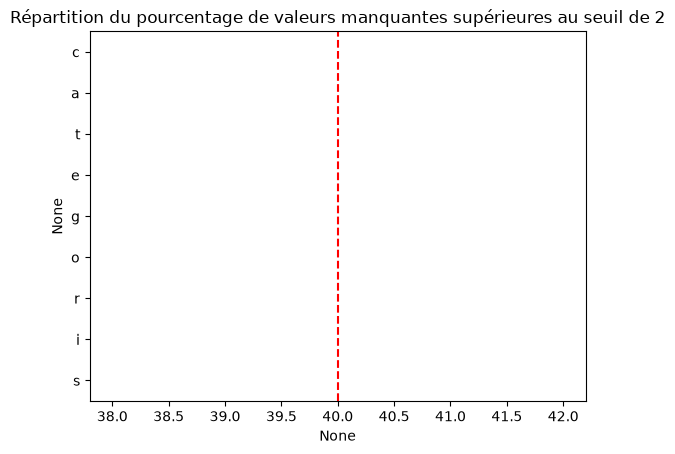

In [56]:
threshold_view = 2

filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");

threshold = 40

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

Gérer les outliers 

Autre optionnel : transformation, robust scaller...

CHOISIR MODELE : comparer diff modèles avec un pré-traitement basique, sélectionner le meilleur modèle

Optimisation

Score et courbe d'apprentissage

AMELIORATION DES DONNEES : sélection des features, réduction de dimensions